

### What this notebook does
1. Loads `master_index.csv` from Notebook 01
2. Resizes all images to 224x224 -> saves to `Data/Processed/`
3. Creates a **stratified-on-(dataset, label)** train/val/test split, per the
   sampling check added to Notebook 01 - this keeps every sensor's share
   consistent across all three splits, instead of only preserving the
   overall Live:Spoof ratio
4. Computes **per-dataset pixel normalization statistics** (mean/std per
   sensor) instead of reusing generic ImageNet statistics for every source
5. Builds a **per-dataset weighted sampler** so small, currently
   under-performing sensors (the two PrintScan subsets) are seen by the
   model proportionally more often during training
6. Defines the PyTorch `Dataset` + transforms (mild augmentation, per-dataset
   normalization) and verifies everything end-to-end




## 1. Import Libraries


In [1]:
# ---------------------------------------------------------------------------
# Standard imports used throughout preprocessing, splitting and the dataset
# pipeline that this notebook builds.
# ---------------------------------------------------------------------------
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image

np.random.seed(42)
torch.manual_seed(42)
print('Libraries loaded \u2713')


Libraries loaded ✓


## 2. Paths Config


In [2]:
# ---------------------------------------------------------------------------
# Same project-wide path convention used in every other notebook.
# ---------------------------------------------------------------------------
SPLITS_DIR    = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits"
PROCESSED_DIR = r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(SPLITS_DIR,    exist_ok=True)

IMG_SIZE      = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print(f'SPLITS_DIR    : {SPLITS_DIR}')
print(f'PROCESSED_DIR : {PROCESSED_DIR}')
print(f'IMG_SIZE      : {IMG_SIZE}')


SPLITS_DIR    : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits
PROCESSED_DIR : C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Processed
IMG_SIZE      : (224, 224)


## 3. Load master_index.csv


In [3]:
# ---------------------------------------------------------------------------
# Read the single labelled index produced by Notebook 01. Every later cell in
# this notebook works from this one table.
# ---------------------------------------------------------------------------
master_csv = os.path.join(SPLITS_DIR, 'master_index.csv')
df_all = pd.read_csv(master_csv)

print(f'Total records : {len(df_all)}')
print(f'Live   (0)    : {(df_all.label==0).sum()}')
print(f'Spoof  (1)    : {(df_all.label==1).sum()}')
print(f'\nPer dataset:')
print(df_all['dataset'].value_counts().to_string())
df_all.head(3)


Total records : 21659
Live   (0)    : 11046
Spoof  (1)    : 10613

Per dataset:
dataset
NDCLD15             7300
IIITD_NewNormal     6022
IIITD_Cogent        3466
IIITD_Vista         3015
PrintScan_Vista     1081
PrintScan_Cogent     775


,path,label,label_name,dataset,subject
0,C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IR...,1,spoof,NDCLD15,nd1S05963
1,C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IR...,1,spoof,NDCLD15,nd1S05963
2,C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IR...,1,spoof,NDCLD15,nd1S05842


## 4. Resize All Images -> Save to Processed


In [4]:
# ---------------------------------------------------------------------------
# Load each raw image, resize to IMG_SIZE, and save as PNG under
# Processed/<dataset>/<live|spoof>/. TIFF files that OpenCV cannot decode
# fall back to Pillow. Unreadable files are dropped from df_all afterwards.
# ---------------------------------------------------------------------------
def preprocess_and_save(row, out_dir, size=IMG_SIZE):
    '''
    Load image -> resize 224x224 -> save as PNG.
    Handles TIFF via PIL fallback.
    Returns the new path, or None if the image could not be read.
    '''
    img = cv2.imread(row['path'])
    if img is None:
        try:
            pil_img = Image.open(row['path']).convert('RGB')
            img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        except Exception:
            return None

    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)

    label_name  = 'live' if row['label'] == 0 else 'spoof'
    save_folder = os.path.join(out_dir, row['dataset'], label_name)
    os.makedirs(save_folder, exist_ok=True)

    filename  = Path(row['path']).stem + '.png'
    save_path = os.path.join(save_folder, filename)
    cv2.imwrite(save_path, img)
    return save_path

print(f'Processing {len(df_all)} images \u2192 {PROCESSED_DIR}')
print('This will take a few minutes...\n')

processed_paths = []
failed = 0
for _, row in tqdm(df_all.iterrows(), total=len(df_all), desc='Resizing'):
    new_path = preprocess_and_save(row, PROCESSED_DIR)
    processed_paths.append(new_path)
    if new_path is None:
        failed += 1

df_all['processed_path'] = processed_paths
df_all = df_all[df_all['processed_path'].notna()].reset_index(drop=True)

print(f'\n\u2705 Done!')
print(f'   Saved   : {len(df_all)}')
print(f'   Failed  : {failed}')
print(f'   Location: {PROCESSED_DIR}')


Processing 21659 images → C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Processed
This will take a few minutes...



Resizing: 100%|██████████| 21659/21659 [08:43<00:00, 41.35it/s]


✅ Done!
   Saved   : 21659
   Failed  : 0
   Location: C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Processed


## 5. Train / Val / Test Split (70 / 15 / 15) - Stratified on (dataset, label)

**This cell is the main fix from this update.** The previous version called
`train_test_split(stratify=df_all['label'])`, which only guarantees the
overall Live:Spoof ratio is preserved across splits - it makes no promise
about any individual dataset's share. As confirmed by the simulation added
to Notebook 01 (Section 12, `dataset_split_check.csv`), stratifying on a
combined `dataset + "_" + label` key instead keeps every sensor's
proportion consistent in train, val and test simultaneously, which is what
this cell now does.


In [5]:
# ---------------------------------------------------------------------------
# Stratified split on the joint (dataset, label) key, not on label alone.
# This is the same strat_key construction validated in Notebook 01's
# per-dataset stratified sampling check (Section 12) - using it here keeps
# the real split consistent with what was simulated and verified there.
# ---------------------------------------------------------------------------
df_all['strat_key'] = df_all['dataset'] + '_' + df_all['label'].astype(str)

train_df, temp_df = train_test_split(
    df_all, test_size=0.30,
    stratify=df_all['strat_key'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['strat_key'], random_state=42
)

train_df = train_df.copy(); train_df['split'] = 'train'
val_df   = val_df.copy();   val_df['split']   = 'val'
test_df  = test_df.copy();  test_df['split']  = 'test'

# strat_key was only needed to drive the split - drop it before saving so it
# doesn't end up as a stray column in every downstream CSV.
for d in (train_df, val_df, test_df):
    d.drop(columns=['strat_key'], inplace=True)

# Save CSVs
train_df.to_csv(os.path.join(SPLITS_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(SPLITS_DIR,   'val.csv'),   index=False)
test_df.to_csv(os.path.join(SPLITS_DIR,  'test.csv'),  index=False)

print('=' * 55)
print('  SPLIT SUMMARY')
print('=' * 55)
print(f"  Train : {len(train_df)} total | Live: {(train_df.label==0).sum()} | Spoof: {(train_df.label==1).sum()}")
print(f"  Val   : {len(val_df)} total | Live: {(val_df.label==0).sum()} | Spoof: {(val_df.label==1).sum()}")
print(f"  Test  : {len(test_df)} total | Live: {(test_df.label==0).sum()} | Spoof: {(test_df.label==1).sum()}")
print('=' * 55)


  SPLIT SUMMARY
  Train : 15161 total | Live: 7732 | Spoof: 7429
  Val   : 3249 total | Live: 1656 | Spoof: 1593
  Test  : 3249 total | Live: 1658 | Spoof: 1591


## 6. Verify Per-Dataset Proportionality of the Real Split

A quick confirmation that the stratified split above actually behaves as
intended: every dataset's share of train/val/test should now closely match
its original share of the full pool, including the two small PrintScan
subsets. This is compared directly against `dataset_split_check.csv` from
Notebook 01 if that file is present.


In [6]:
# ---------------------------------------------------------------------------
# For every dataset, compare its share of the ORIGINAL pool against its
# share in each of the three REAL splits just written to disk. This is the
# same comparison Notebook 01 simulated in advance - running it again here,
# on the actual split, confirms the simulation's prediction held.
# ---------------------------------------------------------------------------
verify_rows = []
total_n = len(df_all)

for ds in df_all['dataset'].unique():
    orig_n   = (df_all['dataset'] == ds).sum()
    orig_pct = round(100 * orig_n / total_n, 2)

    train_pct = round(100 * (train_df['dataset'] == ds).sum() / len(train_df), 2)
    val_pct   = round(100 * (val_df['dataset']   == ds).sum() / len(val_df),   2)
    test_pct  = round(100 * (test_df['dataset']  == ds).sum() / len(test_df),  2)

    max_gap = max(abs(train_pct - orig_pct), abs(val_pct - orig_pct), abs(test_pct - orig_pct))

    verify_rows.append({
        'Dataset':            ds,
        'Original Share (%)': orig_pct,
        'Train Share (%)':    train_pct,
        'Val Share (%)':      val_pct,
        'Test Share (%)':     test_pct,
        'Max Gap (pp)':       round(max_gap, 2),
    })

verify_df = pd.DataFrame(verify_rows).sort_values('Max Gap (pp)', ascending=False)
print('Per-dataset share consistency across the REAL split:')
print(verify_df.to_string(index=False))

worst_gap = verify_df['Max Gap (pp)'].max()
if worst_gap <= 0.5:
    print(f"\n\u2705 Every dataset's share stays within 0.5 percentage points across "
          f"train/val/test (worst gap: {worst_gap:.2f} pp).")
else:
    print(f"\n\u26a0\ufe0f  Largest share gap observed: {worst_gap:.2f} pp. This is "
          f"expected to be small now that the split is stratified on (dataset, "
          f"label) jointly; investigate further if this exceeds 1-2 pp.")

# Optional cross-check against Notebook 01's pre-flight simulation, if saved.
check_csv = os.path.join(SPLITS_DIR, 'dataset_split_check.csv')
if os.path.exists(check_csv):
    nb01_check = pd.read_csv(check_csv)
    print(f"\nNotebook 01's simulated check is available at {check_csv} "
          f"for side-by-side comparison with the table above.")


Per-dataset share consistency across the REAL split:
         Dataset  Original Share (%)  Train Share (%)  Val Share (%)  Test Share (%)  Max Gap (pp)
 PrintScan_Vista                4.99             4.99           5.02            4.99          0.03
 IIITD_NewNormal               27.80            27.80          27.79           27.82          0.02
PrintScan_Cogent                3.58             3.58           3.57            3.57          0.01
     IIITD_Vista               13.92            13.92          13.91           13.91          0.01
         NDCLD15               33.70            33.70          33.70           33.70          0.00
    IIITD_Cogent               16.00            16.00          16.00           16.00          0.00

✅ Every dataset's share stays within 0.5 percentage points across train/val/test (worst gap: 0.03 pp).

Notebook 01's simulated check is available at C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits\dataset_split_check.csv for side-by-si

## 7. Per-Dataset Normalization Statistics

Instead of normalizing every image with the generic ImageNet mean/std
regardless of which sensor captured it, this section computes a separate
mean and standard deviation **per dataset** from the training split. NDCLD15
and PrintScan are captured under different illumination/sensor conditions
than IIITD, so reusing one fixed normalization constant for all six sources
amplifies that domain gap rather than correcting it - this was identified as
one of the two main contributors to the high BPCER previously observed on
the PrintScan subsets.

These statistics are computed once here and saved to
`dataset_norm_stats.json`, so Notebook 03 (and any other notebook that needs
to reproduce this exact normalization) can load them without recomputing.


In [7]:
# ---------------------------------------------------------------------------
# Per-dataset pixel mean/std, computed in grayscale over a sample of TRAIN
# images only (never over val/test, to avoid leaking split information into
# preprocessing statistics). A sample of up to 300 images per dataset is
# used - large enough to be a stable estimate, small enough to stay fast.
# ---------------------------------------------------------------------------
SAMPLE_PER_DATASET = 300
rng = np.random.default_rng(42)

dataset_stats = {}
for ds in train_df['dataset'].unique():
    paths = train_df[train_df.dataset == ds]['processed_path'].tolist()
    sample = rng.choice(paths, size=min(SAMPLE_PER_DATASET, len(paths)), replace=False)

    pixels = []
    for p in sample:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.append(img.flatten())

    all_px = np.concatenate(pixels).astype(np.float64) / 255.0
    dataset_stats[ds] = {
        'mean': float(all_px.mean()),
        'std':  float(all_px.std()),
        'n_sampled': len(sample),
    }

print('Per-dataset normalization statistics (from train split only):')
print(f"{'Dataset':20s} {'mean':>8} {'std':>8} {'n_sampled':>10}")
for ds, stats in dataset_stats.items():
    print(f"{ds:20s} {stats['mean']:8.4f} {stats['std']:8.4f} {stats['n_sampled']:10d}")

# Reference: generic ImageNet grayscale-equivalent mean for comparison.
imagenet_gray_mean = sum(IMAGENET_MEAN) / 3
print(f"\nFor reference, ImageNet RGB-channel-average mean used previously: "
      f"{imagenet_gray_mean:.4f}")
print("Datasets whose mean differs substantially from this reference are the "
      "ones most likely to have suffered from reusing a single fixed "
      "normalization constant.")

stats_path = os.path.join(SPLITS_DIR, 'dataset_norm_stats.json')
with open(stats_path, 'w') as f:
    json.dump(dataset_stats, f, indent=2)
print(f"\n\u2705 dataset_norm_stats.json saved \u2192 {stats_path}")


Per-dataset normalization statistics (from train split only):
Dataset                  mean      std  n_sampled
IIITD_Cogent           0.4897   0.2352        300
IIITD_NewNormal        0.4927   0.2465        300
IIITD_Vista            0.2554   0.1183        300
PrintScan_Cogent       0.3755   0.1711        300
NDCLD15                0.5724   0.2605        300
PrintScan_Vista        0.3716   0.1335        300

For reference, ImageNet RGB-channel-average mean used previously: 0.4490
Datasets whose mean differs substantially from this reference are the ones most likely to have suffered from reusing a single fixed normalization constant.

✅ dataset_norm_stats.json saved → C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\splits\dataset_norm_stats.json


## 8. Handle Class Imbalance - Class Weights + Per-Dataset Sample Weights

This section now computes **two** kinds of weighting, both passed forward to
later cells/notebooks:

1. **Class weights** (Live vs Spoof) - as before, for completeness. The
   pooled dataset is close to balanced overall (~51% Live / 49% Spoof) so
   this term alone has only a small effect.
2. **Per-dataset sample weights** (new) - used to build a `WeightedRandomSampler`
   in Section 10, so that small, currently under-performing sensors
   (PrintScan_Cogent, PrintScan_Vista) are sampled proportionally more often
   during training instead of appearing in only ~8% of batches by raw count.
   The weight values below were chosen based on each dataset's size and its
   measured evaluation performance: severely under-represented and
   under-performing datasets get the largest boost.


In [8]:
# ---------------------------------------------------------------------------
# 1) Class weights (Live vs Spoof) - unchanged in spirit from the previous
#    version, computed on the train split.
# ---------------------------------------------------------------------------
live_count  = (train_df.label==0).sum()
spoof_count = (train_df.label==1).sum()
total       = len(train_df)

weight_live  = round(total / (2 * live_count),  4)
weight_spoof = round(total / (2 * spoof_count), 4)

CLASS_WEIGHTS = torch.tensor([weight_live, weight_spoof], dtype=torch.float)

print(f'Live  count  : {live_count}  \u2192 weight: {weight_live}')
print(f'Spoof count  : {spoof_count} \u2192 weight: {weight_spoof}')
print(f'CLASS_WEIGHTS: {CLASS_WEIGHTS}')
print('\u2192 These will be passed to CrossEntropyLoss in Notebook 03')


Live  count  : 7732  → weight: 0.9804
Spoof count  : 7429 → weight: 1.0204
CLASS_WEIGHTS: tensor([0.9804, 1.0204])
→ These will be passed to CrossEntropyLoss in Notebook 03


In [9]:
# ── CELL 8 (UPDATED): Per-Dataset Sample Weights + Within-Dataset Live Boost ──
# ---------------------------------------------------------------------------
# Diagnostic confirmed the real problem: it's not just that PrintScan
# subsets are SMALL, it's that each dataset has its OWN internal live:spoof
# imbalance, and PrintScan_Vista's is the most severe (Live=134, Spoof=622,
# ratio 1:4.6) - far worse than PrintScan_Cogent (1:3.0) or any other
# dataset (~1:2.0). This explains why Vista's BPCER (65.52%) is worse than
# Cogent's (41.38%) even after applying the same dataset-level 3.0x boost -
# a single dataset-level weight cannot fix an imbalance that exists WITHIN
# the dataset itself.
#
# Fix: combine the existing dataset-level weight (boosts small/weak datasets
# overall) with a NEW within-dataset live-boost factor (boosts the
# minority class specifically inside each dataset, proportional to how
# skewed that specific dataset is).
# ---------------------------------------------------------------------------

# ── CELL: Per-Dataset Sample Weights (FIXED - no double-boosting) ──
DATASET_SAMPLE_WEIGHTS = {
    'NDCLD15':          1.0,
    'IIITD_NewNormal':  1.0,
    'IIITD_Cogent':     1.3,
    'IIITD_Vista':      1.0,
    'PrintScan_Cogent': 3.0,
    'PrintScan_Vista':  3.0,
}

def compute_within_dataset_live_boost(df, max_boost=2.0):
    """Capped boost — prevents extreme over-sampling of the same few images."""
    boost = pd.Series(1.0, index=df.index)
    for ds in df['dataset'].unique():
        sub = df[df['dataset'] == ds]
        live_n, spoof_n = (sub.label==0).sum(), (sub.label==1).sum()
        if live_n == 0:
            continue
        live_boost = min(spoof_n / live_n, max_boost)
        boost.loc[sub[sub.label==0].index] = live_boost
    return boost

live_boost = compute_within_dataset_live_boost(train_df, max_boost=2.0)

dataset_level_weight = train_df['dataset'].map(
    lambda ds: DATASET_SAMPLE_WEIGHTS.get(ds, 1.0)
).values

sample_weights = (dataset_level_weight * live_boost.values).copy()

train_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(train_df), replacement=True
)

print('Per-dataset live boost (capped at 2.0x):')
for ds in train_df['dataset'].unique():
    sub = train_df[train_df['dataset']==ds]
    live_n, spoof_n = (sub.label==0).sum(), (sub.label==1).sum()
    b = min(spoof_n/live_n, 2.0) if live_n > 0 else 0
    print(f'  {ds:20s}: Live boost = {b:.2f}x')
# Combine: dataset-level weight (fixed multiplier) x within-dataset live boost
dataset_level_weight = train_df['dataset'].map(
    lambda ds: DATASET_SAMPLE_WEIGHTS.get(ds, 1.0)
).values

sample_weights = (dataset_level_weight * live_boost.values).copy()

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_df),
    replacement=True,
)

print('\nFinal effective per-epoch share per dataset (combined weighting):')
effective_share = (
    train_df.assign(w=sample_weights)
    .groupby('dataset')['w'].sum()
    .pipe(lambda s: 100 * s / s.sum())
    .round(2)
)
for ds in effective_share.index:
    raw_pct = round(100 * (train_df['dataset'] == ds).sum() / len(train_df), 2)
    print(f'  {ds:20s}: raw={raw_pct:6.2f}%  ->  weighted={effective_share[ds]:6.2f}%')

Per-dataset live boost (capped at 2.0x):
  IIITD_Cogent        : Live boost = 1.98x
  IIITD_NewNormal     : Live boost = 0.00x
  IIITD_Vista         : Live boost = 2.00x
  PrintScan_Cogent    : Live boost = 2.00x
  NDCLD15             : Live boost = 1.95x
  PrintScan_Vista     : Live boost = 2.00x

Final effective per-epoch share per dataset (combined weighting):
  IIITD_Cogent        : raw= 16.00%  ->  weighted= 22.70%
  IIITD_NewNormal     : raw= 27.80%  ->  weighted=  0.00%
  IIITD_Vista         : raw= 13.92%  ->  weighted= 15.22%
  NDCLD15             : raw= 33.70%  ->  weighted= 36.58%
  PrintScan_Cogent    : raw=  3.58%  ->  weighted= 11.03%
  PrintScan_Vista     : raw=  4.99%  ->  weighted= 14.46%


## 9. PyTorch Dataset Class + Transforms (Per-Dataset Normalization)

The `IrisDataset` class below is updated to normalize each image using its
**own dataset's** mean/std (from `dataset_norm_stats.json`, Section 7)
instead of the fixed ImageNet constants used previously. Augmentation
strength is unchanged from before - mild flip/rotation/colour-jitter,
deliberately kept gentle so it does not wash out genuine print-attack or
contact-lens texture cues, as noted in the original version of this
notebook.


In [10]:
# ---------------------------------------------------------------------------
# Train: with mild augmentation (unchanged from the previous version).
# Kept deliberately mild so we don't wash out genuine PAD texture/colour
# cues (contact-lens edge, print artifacts).
# Normalization is now applied INSIDE IrisDataset.__getitem__ using each
# sample's own dataset's mean/std, rather than baked into this Compose with
# one fixed ImageNet constant for every source.
# ---------------------------------------------------------------------------
train_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
])

# Val/Test: no augmentation, same reasoning as before.
val_transform = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
])

class IrisDataset(Dataset):
    '''
    Generic Iris PAD Dataset.
    Reads from CSV: processed_path, label, dataset
    label: 0=live, 1=spoof

    dataset_filter: list of dataset names to include (None = all)
    norm_stats:     dict of {dataset_name: {'mean':..., 'std':...}} loaded
                    from dataset_norm_stats.json. Each image is normalized
                    using its OWN dataset's stats, replicated across the 3
                    RGB channels, rather than one fixed ImageNet constant.
    '''
    def __init__(self, csv_path, transform=None, dataset_filter=None, norm_stats=None):
        self.df = pd.read_csv(csv_path)
        if dataset_filter:
            self.df = self.df[self.df['dataset'].isin(dataset_filter)].reset_index(drop=True)
        self.transform  = transform
        self.norm_stats = norm_stats or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['processed_path']).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)  # -> tensor in [0, 1], not yet normalized

        ds = row['dataset']
        if ds in self.norm_stats:
            mean = self.norm_stats[ds]['mean']
            std  = self.norm_stats[ds]['std']
        else:
            # Fall back to the generic ImageNet grayscale-equivalent constant
            # for any dataset missing from norm_stats (should not normally
            # happen, since Section 7 computes stats for every train-split
            # dataset, but this keeps val/test safe if a dataset appears
            # there that had zero samples in train for some reason).
            mean = sum(IMAGENET_MEAN) / 3
            std  = sum(IMAGENET_STD) / 3

        image = (image - mean) / (std + 1e-6)
        return image, label

print('IrisDataset class defined (per-dataset normalization) \u2713')
print('train_transform + val_transform ready \u2713 (normalization now happens inside IrisDataset)')


IrisDataset class defined (per-dataset normalization) ✓
train_transform + val_transform ready ✓ (normalization now happens inside IrisDataset)


## 10. Build DataLoaders (Weighted Sampler on Train)


In [11]:
# ---------------------------------------------------------------------------
# Load the per-dataset normalization statistics saved in Section 7, then
# build the three datasets and their loaders. The train loader uses the
# WeightedRandomSampler built in Section 8 (sampler=... ), which means
# shuffle must NOT also be set to True - the two are mutually exclusive in
# PyTorch's DataLoader.
# ---------------------------------------------------------------------------
with open(os.path.join(SPLITS_DIR, 'dataset_norm_stats.json')) as f:
    norm_stats = json.load(f)

train_ds = IrisDataset(os.path.join(SPLITS_DIR, 'train.csv'), train_transform, norm_stats=norm_stats)
val_ds   = IrisDataset(os.path.join(SPLITS_DIR, 'val.csv'),   val_transform,   norm_stats=norm_stats)
test_ds  = IrisDataset(os.path.join(SPLITS_DIR, 'test.csv'),  val_transform,   norm_stats=norm_stats)

train_loader = DataLoader(train_ds, batch_size=32, sampler=train_sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,         num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,         num_workers=0)

images, labels = next(iter(train_loader))
print(f'Batch shape  : {images.shape}')
print(f'Labels       : {labels[:8]}')
print(f'Pixel range  : [{images.min():.2f}, {images.max():.2f}]')
print(f'\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Batch shape  : torch.Size([32, 3, 224, 224])
Labels       : tensor([0, 0, 0, 1, 0, 1, 1, 1])
Pixel range  : [-2.78, 6.29]

Train: 15161 | Val: 3249 | Test: 3249


## 11. Augmented Batch Visualization


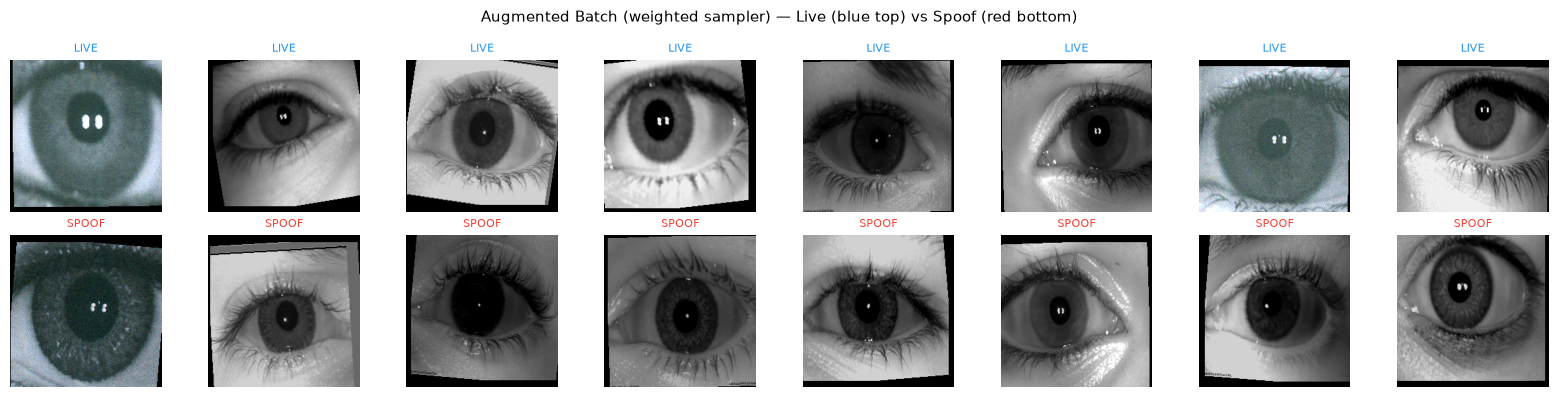

Saved → augmented_batch.png


In [12]:
# ---------------------------------------------------------------------------
# Display one batch from the (weighted-sampled) train loader. Denormalize
# using each image's per-dataset stats is not practical for a mixed batch
# display, so this uses an approximate global denorm purely for visualization
# - this does not affect what the model actually trains on.
# ---------------------------------------------------------------------------
def denorm_approx(tensor):
    approx_mean = sum(IMAGENET_MEAN) / 3
    approx_std  = sum(IMAGENET_STD) / 3
    return torch.clamp(tensor * approx_std + approx_mean, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Augmented Batch (weighted sampler) \u2014 Live (blue top) vs Spoof (red bottom)', fontsize=11)
live_shown = spoof_shown = 0

for img_t, lbl in zip(images, labels):
    img_np = denorm_approx(img_t).permute(1,2,0).numpy()
    if lbl == 0 and live_shown < 8:
        axes[0][live_shown].imshow(img_np)
        axes[0][live_shown].set_title('LIVE', color='#2196F3', fontsize=8)
        axes[0][live_shown].axis('off')
        live_shown += 1
    elif lbl == 1 and spoof_shown < 8:
        axes[1][spoof_shown].imshow(img_np)
        axes[1][spoof_shown].set_title('SPOOF', color='#F44336', fontsize=8)
        axes[1][spoof_shown].axis('off')
        spoof_shown += 1
    if live_shown == 8 and spoof_shown == 8:
        break

plt.tight_layout()
plt.savefig(os.path.join(SPLITS_DIR, 'augmented_batch.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved \u2192 augmented_batch.png')


## 12. Augmentation Comparison - Original vs 5 Variants


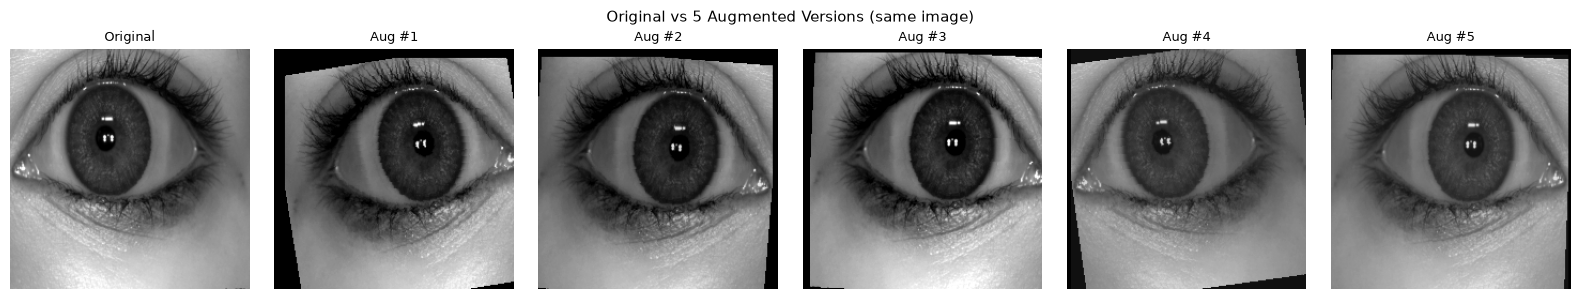

Saved → augmentation_comparison.png


In [13]:
# ---------------------------------------------------------------------------
# Show one sample image and 5 differently-augmented copies of it, using the
# raw (un-normalized) train_transform output, since normalization no longer
# lives inside this Compose object.
# ---------------------------------------------------------------------------
sample_row = pd.read_csv(os.path.join(SPLITS_DIR,'train.csv')).iloc[0]
orig_img   = Image.open(sample_row['processed_path']).convert('RGB')

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
fig.suptitle('Original vs 5 Augmented Versions (same image)', fontsize=11)

axes[0].imshow(orig_img)
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

for i in range(1, 6):
    aug    = train_transform(orig_img)  # tensor in [0, 1], no normalization applied
    img_np = aug.permute(1,2,0).numpy()
    axes[i].imshow(img_np)
    axes[i].set_title(f'Aug #{i}', fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SPLITS_DIR, 'augmentation_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved \u2192 augmentation_comparison.png')


## 13. Done - Summary


In [14]:
# ---------------------------------------------------------------------------
# Final summary of everything this notebook produced. Notebook 03 should
# load train.csv / val.csv / test.csv, dataset_norm_stats.json, and rebuild
# the same IrisDataset + WeightedRandomSampler pattern defined above.
# ---------------------------------------------------------------------------

print(f'  Processed images \u2192 {PROCESSED_DIR}')
print(f'  train.csv : {len(train_ds)} images')
print(f'  val.csv   : {len(val_ds)} images')
print(f'  test.csv  : {len(test_ds)} images')
print(f'  CLASS_WEIGHTS         : live={CLASS_WEIGHTS[0]:.3f} | spoof={CLASS_WEIGHTS[1]:.3f}')
print(f'  dataset_norm_stats.json saved with {len(norm_stats)} datasets')
print(f'  Per-dataset sampler   : PrintScan_Cogent/Vista weighted 3.0x')




  Processed images → C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Data\Processed
  train.csv : 15161 images
  val.csv   : 3249 images
  test.csv  : 3249 images
  CLASS_WEIGHTS         : live=0.980 | spoof=1.020
  dataset_norm_stats.json saved with 6 datasets
  Per-dataset sampler   : PrintScan_Cogent/Vista weighted 3.0x
